In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('seaborn-v0_8')

In [46]:
data = pd.read_csv('combined_data_carbon.csv', usecols=["Iso3cur", "Iso2/Iso3", "Sample description"]) #, header=0, usecols=["First Name", "Sex", "Email"]
# printing dataframe
df = data.copy()
x_arr = df["Iso3cur"].to_numpy() 
y_arr = df["Iso2/Iso3"].to_numpy() 
mean_y_arr = df["Iso2/Iso3"].mean()

par, cov_matrix = np.polyfit(x_arr, y_arr, 1, cov=True)
error = np.sqrt(np.diag(cov_matrix))

def r_squared(x,y):
    return np.corrcoef(x,y)[1, 0]**2

#cor_matrix = np.corrcoef(channel, energy)
#print(cor_matrix[0,1].round(3))
print(f"R-squared: {r_squared(x_arr, y_arr):.4f}")

print(f"Slope: {par[0]:.2f} +- {error[0]:.2f}")
print(f"Intercept: {par[1]:.4f} +- {error[1]:.8f}")



R-squared: 0.0128
Slope: 5.57 +- 0.64
Intercept: 0.0103 +- 0.00000863


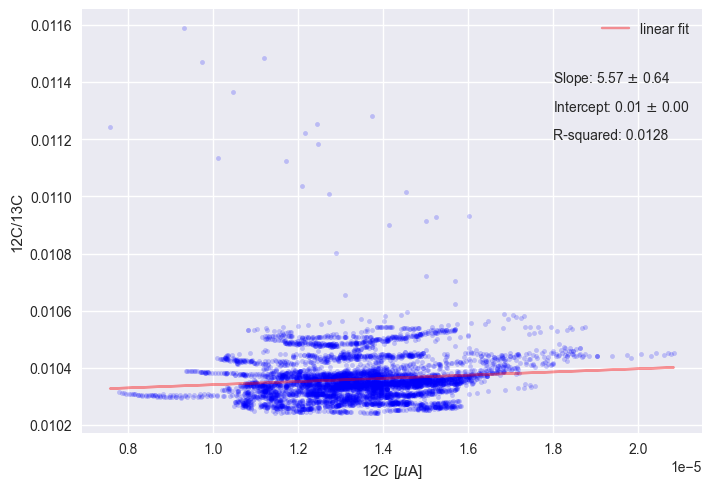

In [72]:
fig, ax = plt.subplots()
ax.plot(x_arr,y_arr,'b.', alpha=0.2)
ax.plot(x_arr, x_arr * par[0] + par[1],'r-', alpha=0.4, label='linear fit')
ax.set_xlabel(r'12C [$\mu$A]')
ax.set_ylabel(r'12C/13C')
plt.text(1.8e-05, 0.0114, f'Slope: {par[0]:.2f} $\pm$ {error[0]:.2f}')
plt.text(1.8e-05, 0.0113, f'Intercept: {par[1]:.2f} $\pm$ {error[1]:.2f}')
plt.text(1.8e-05, 0.0112, f'R-squared: {r_squared(x_arr, y_arr):.4f}')
plt.legend(loc=0)
plt.show()

In [65]:
# BL, STD, Muestras
samples_df = df.loc[df['Sample description'].str.contains(r'\b(?!.*BL|.*STD)\w+\b', regex=True)]
standard_df = df.loc[df['Sample description'].str.contains(r'\b\w*STD\w*\b', regex=True)]
blank_df = df.loc[df['Sample description'].str.contains(r'\b\w*BL\w*\b', regex=True)]

samples_df = samples_df.reset_index(drop=True)
standard_df = standard_df.reset_index(drop=True)
blank_df = blank_df.reset_index(drop=True)

samples_df.to_csv('samples.csv')
standard_df.to_csv('standard.csv')
blank_df.to_csv('blank.csv')
print(standard_df)


    Sample description   Iso3cur  Iso2/Iso3
0           OXA II STD  0.000013   0.010454
1           OXA II STD  0.000013   0.010451
2           OXA II STD  0.000013   0.010449
3           OXA II STD  0.000013   0.010448
4           OXA II STD  0.000013   0.010448
..                 ...       ...        ...
399         OXA II STD  0.000015   0.010445
400         OXA II STD  0.000015   0.010443
401         OXA II STD  0.000015   0.010444
402         OXA II STD  0.000015   0.010444
403         OXA II STD  0.000015   0.010443

[404 rows x 3 columns]


In [ ]:
# df.to_csv('data_out.csv', index= False) 